# Fixed final time rendez-vous in CR3BP with soft terminal constraint

Yuri Shimane, 2025/12/05

In [9]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
sys.path.append("..")

import scocp

We use the CR3BP dynamics continuous-time control:

$$
\dot{\boldsymbol{x}} = \begin{bmatrix}
\dot{\boldsymbol{r}} \\ \dot{\boldsymbol{v}}
\end{bmatrix}
=
\boldsymbol{f}(\boldsymbol{x}, \boldsymbol{u})
= 
\begin{bmatrix}
    \boldsymbol{v} \\
    -\dfrac{1-\mu}{r_1^3}\boldsymbol{r}_1 - \dfrac{\mu}{r_2^3}\boldsymbol{r}_2 - \boldsymbol{\omega} \times (\boldsymbol{\omega} \times \boldsymbol{r}) - 2\boldsymbol{\omega} \times \boldsymbol{r}
\end{bmatrix}
+
\begin{bmatrix}
    0_{3 \times 1} \\ I_3
\end{bmatrix}
\boldsymbol{u}
$$

Using the standard normalization in CR3BP, $\boldsymbol{\omega} = [0,0,1]^T$.

In [51]:
# setup dynamics
mu = 1.215058560962404e-02
integrator = scocp.ScipyIntegrator(nx=6, nu=3, rhs=scocp.control_rhs_cr3bp, rhs_stm=scocp.control_rhs_cr3bp_stm,
                                   impulsive=False, args=(mu,[0.0,0.0,0.0]),
                                   method='DOP853', reltol=1e-12, abstol=1e-12)

### Problem definition

We solve the following problem

$$
\begin{aligned}
\min_{\substack{\boldsymbol{x}_0,\ldots,\boldsymbol{x}_{N} \\ \boldsymbol{u}_0,\ldots,\boldsymbol{u}_{N-1}}} \quad& (\boldsymbol{x}_N - \boldsymbol{x}_f)^T Q_f (\boldsymbol{x}_N - \boldsymbol{x}_f) + \sum_{k=0}^{N-1} R \| \boldsymbol{u}_k \|_2 
\\ \text{s.t.}\quad& 
    \boldsymbol{x}_{k+1} = \boldsymbol{x}_{k} + \int_{t_k}^{t_{k+1}} \boldsymbol{f}(\boldsymbol{x}_k, \boldsymbol{u}_k)\mathrm{d}t \quad k = 0,\ldots,N-1
\\&
    \| \boldsymbol{u}_k \|_2 \leq u_{\max} \quad k = 0,\ldots,N-1
\\&
    \boldsymbol{x}_0 = \text{fixed}
\end{aligned}
$$

In [52]:
# boundary conditions
x0 = np.array([
    1.0809931218390707E+00,
    0.0,
    -2.0235953267405354E-01,
    0.0,
    -1.9895001215078018E-01,
    0.0])
period_0 = 2.3538670417546639E+00

xf = np.array([
    1.1648780946517576,
    0.0,
    -1.1145303634437023E-1,
    0.0,
    -2.0191923237095796E-1,
    0.0])
period_f = 3.3031221822879884

# we will propagate the boundary conditions for plotting later
sol_lpo0 = integrator.solve([0, period_0], x0, get_ODESolution=True)
sol_lpo1 = integrator.solve([0, period_f], xf, get_ODESolution=True)

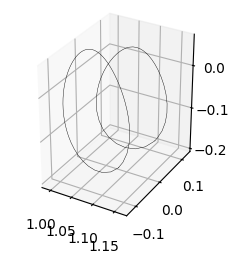

In [57]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(2,2,1,projection='3d')
ax.plot(sol_lpo0.y[0,:], sol_lpo0.y[1,:], sol_lpo0.y[2,:], 'k-', lw=0.3)
ax.plot(sol_lpo1.y[0,:], sol_lpo1.y[1,:], sol_lpo1.y[2,:], 'k-', lw=0.3)
ax.set_aspect('equal')
plt.show()

We now define the time grid. We discretize with `N` equally spaced nodes.

In [27]:
# transfer problem discretization
N = 30
tf = (period_0 + period_f) / 2
times = np.linspace(0, tf, N)

### Define SCP problem class

We will now define the SCP problem class. We define a custom class that inherits the `scocp.ContinuousControlSCOCP` to define a rendez-vous problem with soft terminal constraint.

In [120]:
class SoftConstrainedFixedTimeRdv(scocp.ContinuousControlSCOCP):
    def __init__(self, x0, xf, umax, Qf, R, *args, **kwargs):
        super().__init__(*args, **kwargs)
        assert len(x0) == self.integrator.nx
        assert len(xf) == self.integrator.nx
        assert Qf.shape == (6,6)
        self.x0 = x0
        self.xf = xf
        self.Qf = Qf
        self.R  = R
        self.umax = umax
        return
        
    def evaluate_objective(self, xs, us, vs, ys=None):
        """Evaluate the objective function"""
        # control cost
        J_u = np.sum(self.R * vs)

        # terminal deviation
        Delta_xf = xs[-1,:] - self.xf
        J_xf = Delta_xf.T @ self.Qf @ Delta_xf
        return J_xf + J_u
    
    def solve_convex_problem(self, xbar, ubar, vbar, ybar=None):
        """Solve the convex subproblem
        
        Args:
            xbar (np.array): `(N, self.integrator.nx)` array of reference state history
            ubar (np.array): `(N-1, self.integrator.nu)` array of reference control history
            vbar (np.array): `(N-1, self.integrator.nv)` array of reference constraint history
        
        Returns:
            (tuple): np.array values of xs, us, vs, xi_dyn, xi_eq, zeta_ineq
        """
        N,nx = xbar.shape
        _,nu = ubar.shape
        Nseg = N - 1
        
        xs = cp.Variable((N, nx), name='state')
        us = cp.Variable((Nseg, nu), name='control')
        vs = cp.Variable((Nseg, 1), name='Gamma')
        xis_dyn = cp.Variable((Nseg,nx), name='xi_dyn')         # slack for dynamics

        # compute objective
        J_u = cp.sum(self.R * vs)
        Delta_xf = xs[-1,:] - self.xf
        J_xf = Delta_xf.T @ self.Qf @ Delta_xf
        penalty = scocp.get_augmented_lagrangian_penalty(self.weight, xis_dyn, self.lmb_dynamics)
        objective_func = J_xf + J_u + penalty
        constraints_objsoc = [cp.SOC(vs[i,0], us[i,:]) for i in range(N-1)]

        if self.augment_Gamma:
            constraints_dyn = [
                xs[i+1,:] == self.Phi_A[i,:,:] @ xs[i,:] + self.Phi_B[i,:,:] @ np.concatenate([us[i,:], vs[i,:]]) + self.Phi_c[i,:] + xis_dyn[i,:]
                for i in range(Nseg)
            ]
        else:
            constraints_dyn = [
                xs[i+1,:] == self.Phi_A[i,:,:] @ xs[i,:] + self.Phi_B[i,:,:] @ us[i,:] + self.Phi_c[i,:] + xis_dyn[i,:]
                for i in range(Nseg)
            ]

        constraints_trustregion = [
            xs[i,:] - xbar[i,:] <=  self.trust_region_radius_x for i in range(N)
        ] + [
            xs[i,:] - xbar[i,:] >= -self.trust_region_radius_x for i in range(N)
        ]
        if self.trust_region_radius_u is not None:
            constraints_trustregion += [
                us[i,:] - ubar[i,:] <=  self.trust_region_radius_u for i in range(Nseg)
            ] + [
                us[i,:] - ubar[i,:] >= -self.trust_region_radius_u for i in range(Nseg)
            ]

        constraints_initial = [xs[0,:] == self.x0]
        
        constraints_control = [
            vs[i,0] <= self.umax for i in range(Nseg)
        ]

        convex_problem = cp.Problem(
            cp.Minimize(objective_func),
            constraints_objsoc + constraints_dyn + constraints_trustregion + constraints_initial + constraints_control)
        convex_problem.solve(solver = self.solver, verbose = self.verbose_solver)
        self.cp_status = convex_problem.status
        return xs.value, us.value, vs.value, None, xis_dyn.value, None, None

In [135]:
# create initial guess
sol_initial = integrator.solve([0, times[-1]], x0, t_eval=times, get_ODESolution=True)
sol_final  = integrator.solve([0, times[-1]], xf, t_eval=times, get_ODESolution=True)

alphas = np.linspace(1,0,N)
xbar = (np.multiply(sol_initial.y, np.tile(alphas, (6,1))) + np.multiply(sol_final.y, np.tile(1-alphas, (6,1)))).T
xbar[0,:] = x0  # overwrite initial state
xbar[-1,:] = xf # overwrite final state
ubar = np.zeros((N-1,3))

In [136]:
# create problem classs
umax = 0.1  # max acceleration
Qf = 1e6 * (N-1) * np.eye(6)
R  = 1
trust_region_radius_x = 0.1
trust_region_radius_u = 0.2
problem = SoftConstrainedFixedTimeRdv(x0, xf, umax, Qf, R, integrator, times,
                                       weight = 1e2,
                                       trust_region_radius_x=trust_region_radius_x,
                                       trust_region_radius_u=trust_region_radius_u)

# problem = scocp.FixedTimeContinuousRdv(x0, xf, umax, integrator, times,
#                                        trust_region_radius_x=trust_region_radius_x,
#                                        trust_region_radius_u=trust_region_radius_u)

# setup algorithm & solve
vbar = np.sum(ubar, axis=1).reshape(-1,1)
tol_feas = 1e-8
tol_opt = 1e-8
algo = scocp.SCvxStar(problem, tol_opt=tol_opt, tol_feas=tol_feas, alpha2=1.5, beta=2)
solution = algo.solve(
    xbar,
    ubar,
    vbar,
    maxiter = 100,
    verbose = True
)
xopt, uopt, vopt, yopt, sols, summary_dict = solution.x, solution.u, solution.v, solution.y, solution.sols, solution.summary_dict
# assert summary_dict["status"] == "Optimal"
# assert summary_dict["chi"][-1] <= tol_feas


|  Iter  |     J0      |   Delta J   |   Delta L   |    chi     |     rho     |   min(r)   |   weight   | step acpt. |
     1   |  2.0062e-01 |  9.0832e+01 |  1.1441e+02 | 4.7431e-01 |  7.9390e-01 | 1.0000e-01 | 1.0000e+02 |    yes     |
     2   |  3.0141e-01 |  1.2954e+02 |  1.6973e+02 | 2.7858e-01 |  7.6320e-01 | 1.5000e-01 | 2.0000e+02 |    yes     |
     3   |  2.6775e-06 |  4.9224e+01 |  5.7337e+01 | 2.6365e-01 |  8.5850e-01 | 2.2500e-01 | 2.0000e+02 |    yes     |
     4   |  1.0638e-05 |  4.6688e+01 |  7.6300e+01 | 1.9640e-01 |  6.1190e-01 | 3.3750e-01 | 4.0000e+02 |    yes     |
     5   |  1.5287e-04 |  8.2323e+01 |  1.2576e+02 | 1.5599e-01 |  6.5458e-01 | 3.3750e-01 | 8.0000e+02 |    yes     |
     6   |  2.5684e-05 | -1.3016e+03 |  4.4659e+01 | 1.3870e+00 | -2.9144e+01 | 3.3750e-01 | 8.0000e+02 |    no      |
     7   |  8.8982e-05 | -6.6832e+02 |  4.3544e+01 | 9.7550e-01 | -1.5348e+01 | 1.6875e-01 | 8.0000e+02 |    no      |
     8   |  1.2009e+00 | -1.5893e+03 |  4.1822e

In [137]:
Delta_xf = xopt[-1,:] - problem.xf
Delta_xf.T @ problem.Qf @ Delta_xf

np.float64(0.0020422014826914445)

### Results

Let's first see how far off we are from the terminal conditions (since we used soft constraints)

In [138]:
xf_diff = xopt[-1] - xf
for i,_x in enumerate(xf_diff):
    print(f"Final state difference Delta x[{i}] = {_x: 1.4e}")

Final state difference Delta x[0] = -6.8332e-05
Final state difference Delta x[1] = -1.8723e-05
Final state difference Delta x[2] = -2.3220e-05
Final state difference Delta x[3] =  1.0746e-05
Final state difference Delta x[4] = -3.3250e-05
Final state difference Delta x[5] = -1.6190e-05


We can now visualize our solution

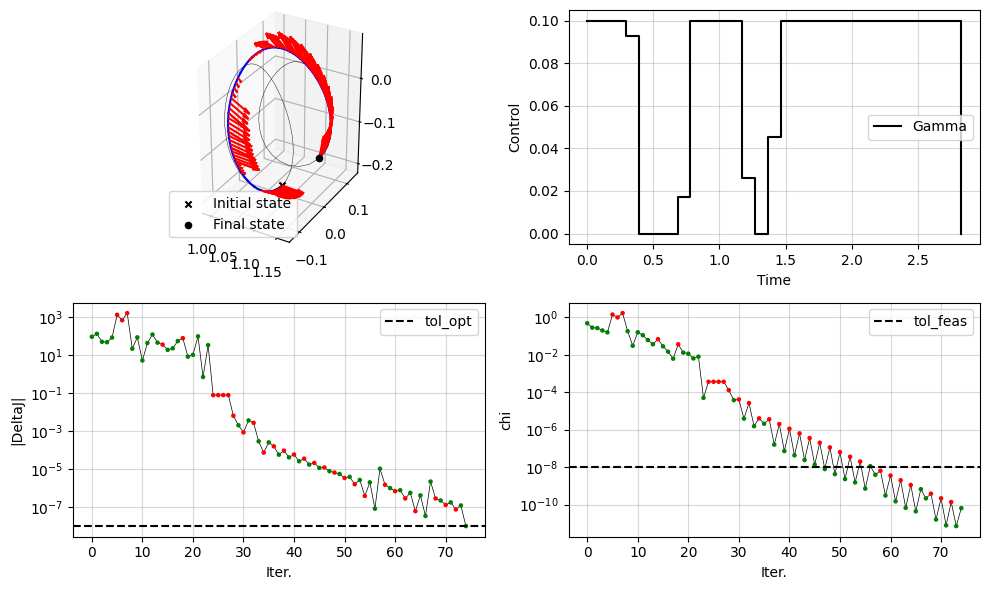

In [139]:
# evaluate nonlinear violations
geq_nl_opt, sols = problem.evaluate_nonlinear_dynamics(xopt, uopt, vopt, steps=5)

# evaluate solution
_, sols_ig = problem.evaluate_nonlinear_dynamics(xbar, ubar, vbar, steps=5)

# plot results
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(2,2,1,projection='3d')
# for (_ts, _ys) in sols_ig:
#     ax.plot(_ys[:,0], _ys[:,1], _ys[:,2], '--', color='grey')
for (_ts, _ys) in sols:
    ax.plot(_ys[:,0], _ys[:,1], _ys[:,2], 'b-')

    # interpolate control
    _us_zoh = scocp.zoh_controls(times, uopt, _ts)
    ax.quiver(_ys[:,0], _ys[:,1], _ys[:,2], _us_zoh[:,0], _us_zoh[:,1], _us_zoh[:,2], color='r', length=0.5)

ax.scatter(x0[0], x0[1], x0[2], marker='x', color='k', label='Initial state')
ax.scatter(xf[0], xf[1], xf[2], marker='o', color='k', label='Final state')
ax.plot(sol_lpo0.y[0,:], sol_lpo0.y[1,:], sol_lpo0.y[2,:], 'k-', lw=0.3)
ax.plot(sol_lpo1.y[0,:], sol_lpo1.y[1,:], sol_lpo1.y[2,:], 'k-', lw=0.3)
ax.set_aspect('equal')
ax.legend()

ax_u = fig.add_subplot(2,2,2)
ax_u.grid(True, alpha=0.5)
ax_u.step(times, np.concatenate((vopt[:,0], [0.0])), label="Gamma", where='post', color='k')
ax_u.set(xlabel="Time", ylabel="Control")
ax_u.legend()

ax_DeltaJ = fig.add_subplot(2,2,3)
ax_DeltaJ.grid(True, alpha=0.5)
algo.plot_DeltaJ(ax_DeltaJ, summary_dict)
ax_DeltaJ.axhline(tol_opt, color='k', linestyle='--', label='tol_opt')
ax_DeltaJ.legend()

ax_DeltaL = fig.add_subplot(2,2,4)
ax_DeltaL.grid(True, alpha=0.5)
algo.plot_chi(ax_DeltaL, summary_dict)
ax_DeltaL.axhline(tol_feas, color='k', linestyle='--', label='tol_feas')
ax_DeltaL.legend()

plt.tight_layout()